In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from core.data import CompressionMetrics
from core.utils import round_sig, make_dual_update
from core.image3d import compress_image3d, reconstruct_image3d

In [3]:
image3d_raw = iio.imread("../sources/drosophila_1slice.y4m")
image3d_raw = image3d_raw[:, :, :, 0]
nt, nx, ny = 30, 30, 30
image3d = image3d_raw[:nt, :nx, :ny]
# plt.imshow(image3d[0], cmap="gray")
# plt.show()

In [4]:
# Hyperparameters
lp_degree = 2.0
block_size = 10
cutoff = None
poly_degrees = np.arange(2, 22, 2) - 1

In [5]:
metrics_list = []
image3d_rec_list = []
for poly_degree in poly_degrees:
    c, X_design, rescale = compress_image3d(
    image3d, poly_degree, block_size, lp_degree, p_inv=True, cutoff=cutoff
    )
    
    c = round_sig(c)
    image3d_rec = reconstruct_image3d(c, X_design, rescale)
    metrics_list.append(CompressionMetrics(image3d, image3d_rec, c))
    image3d_rec_list.append(image3d_rec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    1.9s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    2.1s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    2.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of 

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.1s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  18 out of  27 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  24 out of  27 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:    0.2s finished


In [6]:
# Extract values
psnr_values = [m.psnr for m in metrics_list]
space_saved_values = [m.space_saved for m in metrics_list]

## Plotting PSNR (dB) vs Polynomial Degree

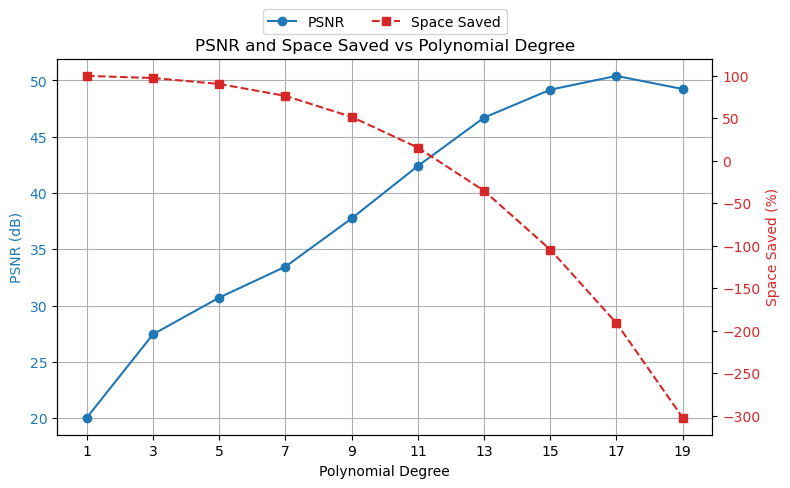

In [7]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot PSNR on primary y-axis
ln1 = ax1.plot(poly_degrees, psnr_values, marker="o", linestyle="-", color="tab:blue", label="PSNR")
ax1.set_xlabel("Polynomial Degree")
ax1.set_ylabel("PSNR (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)
ax1.set_xticks(poly_degrees)

# Plot space saved on secondary y-axis
ax2 = ax1.twinx()
ln2 = ax2.plot(poly_degrees, space_saved_values, marker="s", linestyle="--", color="tab:red", label="Space Saved")
ax2.set_ylabel("Space Saved (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends and place outside top-left
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title("PSNR and Space Saved vs Polynomial Degree")
plt.tight_layout()
plt.savefig("../results/image3d/drosophila_1slice/plots/psnr__pinv__bs=%s__cutoff=%s__lp=%s__poly_deg=%s-%s.png" % (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[9]))
plt.show()


## Space Saved (%) vs Plotting PSNR (dB)

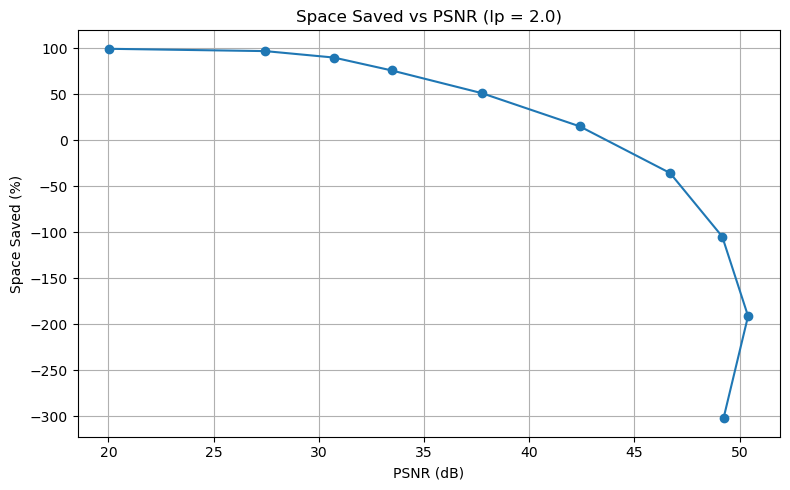

In [8]:
# Create figure and primary axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot PSNR vs space saved
ax.plot(psnr_values, space_saved_values, marker="o", linestyle="-")
ax.set_xlabel("PSNR (dB)")
ax.set_ylabel("Space Saved (%)")
ax.grid(True)

plt.title("Space Saved vs PSNR (lp = %s)" % lp_degree)
plt.tight_layout()
plt.savefig("../results/image3d/drosophila_1slice/plots/space__vs__psnr__pinv__bs=%s__cutoff=%s__lp=%s__poly_deg=%s-%s.png" % (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[9]))
plt.show()

## Verify visual integrity

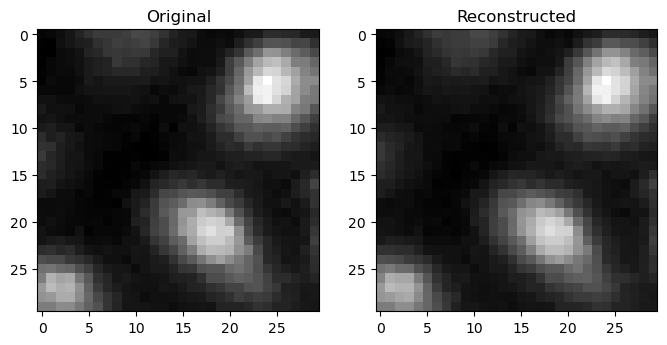

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

im_orig = ax[0].imshow(image3d[0], cmap='gray')
ax[0].set_title("Original")

# Choose which reconstruction of the video you wish to see
idx_rec = 5
im_rec = ax[1].imshow(image3d_rec_list[idx_rec][0], cmap='gray')
ax[1].set_title("Reconstructed")

update = make_dual_update(image3d, image3d_rec_list[idx_rec], im_orig, im_rec)
ani = animation.FuncAnimation(fig, update, frames=len(image3d), interval=200, blit=True)

In [10]:
from IPython.display import HTML
HTML(ani.to_jshtml())